In [1]:
# Import necessary libraries for machine learning analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Machine Learning Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.naive_bayes import GaussianNB

# For warnings
import warnings
warnings.filterwarnings('ignore')



# Assignment 5: Machine Learning Comparison on Iris Dataset

## Objective
The goal is to predict the "class" label using various machine learning methods including SVMs, random forests, neural networks, and additional methods like naive bayes. We will compare their performance using cross-validation and multiple evaluation metrics.

In [2]:
# Load the Iris dataset
# Reading the iris.data file from the iris folder
iris_data_path = r'c:\Users\jland\OneDrive\Emory Essentials\CLASSES Fall 2025\Computing\datasci530fall2025\Assignments\iris\iris.data'

# Column names for the iris dataset
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

# Load the data
df = pd.read_csv(iris_data_path, names=column_names)

# Display basic information about the dataset)
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
df.head()

Dataset shape: (150, 5)

First few rows:


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Summary Statistics

#### We have a dataset with 150 observations split into 3 categories: Setosa, Versicolor, and Virginica.

In [3]:
# Dataset Description and Exploratory Data Analysis
print("="*50)
print("DATASET DESCRIPTION")
print("="*50)

# Basic dataset information
print(f"Number of rows: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")  # Excluding the target variable
print(f"Target variable: 'class'")

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Class distribution
print("\nClass distribution:")
class_counts = df['class'].value_counts()
print(class_counts)

# Proportions of each class
print("\nClass proportions:")
class_proportions = df['class'].value_counts(normalize=True)
for class_name, proportion in class_proportions.items():
    print(f"{class_name}: {proportion:.3f} ({proportion*100:.1f}%)")

# Basic statistics for features
print("\nBasic statistics for features:")
df.describe()

DATASET DESCRIPTION
Number of rows: 150
Number of features: 4
Target variable: 'class'

Missing values: 0

Class distribution:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Class proportions:
Iris-setosa: 0.333 (33.3%)
Iris-versicolor: 0.333 (33.3%)
Iris-virginica: 0.333 (33.3%)

Basic statistics for features:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Summary statistics for each class of iris
print("="*60)
print("SUMMARY STATISTICS BY CLASS")
print("="*60)

# Get unique classes
classes = df['class'].unique()
print(f"Classes found: {classes}")
print()

# Summary statistics for each class
for iris_class in classes:
    print(f"Class: {iris_class}")
    print("-" * 40)
    
    # Filter data for this class
    class_data = df[df['class'] == iris_class]
    
    # Display count
    print(f"Number of samples: {len(class_data)}")
    
    # Summary statistics for numerical features
    numerical_features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
    summary_stats = class_data[numerical_features].describe()
    
    print("\nSummary Statistics:")
    print(summary_stats)
    print()
    
print("="*60)

# Create a comparison table with means for each class
print("MEAN VALUES COMPARISON BY CLASS")
print("="*60)

mean_by_class = df.groupby('class')[numerical_features].mean()
print("Mean values for each feature by class:")
print(mean_by_class.round(3))
print()

# Standard deviations by class
print("STANDARD DEVIATIONS BY CLASS")
print("="*40)
std_by_class = df.groupby('class')[numerical_features].std()
print("Standard deviations for each feature by class:")
print(std_by_class.round(3))

SUMMARY STATISTICS BY CLASS
Classes found: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Class: Iris-setosa
----------------------------------------
Number of samples: 50

Summary Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count      50.00000    50.000000     50.000000     50.00000
mean        5.00600     3.418000      1.464000      0.24400
std         0.35249     0.381024      0.173511      0.10721
min         4.30000     2.300000      1.000000      0.10000
25%         4.80000     3.125000      1.400000      0.20000
50%         5.00000     3.400000      1.500000      0.20000
75%         5.20000     3.675000      1.575000      0.30000
max         5.80000     4.400000      1.900000      0.60000

Class: Iris-versicolor
----------------------------------------
Number of samples: 50

Summary Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count     50.000000    50.000000     50.000000    50.000000
mean       5.936000     2.770000  

# Machine Learning Model Comparison

Now we'll implement and compare different machine learning algorithms to predict iris species. We'll start with Support Vector Machines (SVM).

In [6]:
# Data Preparation for Machine Learning
print("="*60)
print("DATA PREPARATION")
print("="*60)

# Step 1: Separate features (X) and target variable (y)
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]  # Features: the 4 measurements
y = df['class']  # Target: the species we want to predict

print(f"Features shape: {X.shape}")  # Shows (150, 4) - 150 samples, 4 features
print(f"Target shape: {y.shape}")    # Shows (150,) - 150 target labels

# Step 2: Split data into training and testing sets
# We'll use 80% for training, 20% for testing
# random_state=42 ensures reproducible results
# stratify=y ensures each set has proportional representation of each class
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducible results
    stratify=y          # Maintains class proportions in both sets
)

print(f"\nTraining set: {X_train.shape[0]} samples")  # Should be 120 samples
print(f"Testing set: {X_test.shape[0]} samples")      # Should be 30 samples

# Step 3: Feature scaling (very important for SVM!)
# SVM is sensitive to the scale of features, so we normalize them
# StandardScaler transforms features to have mean=0 and std=1
scaler = StandardScaler()                    # Create the scaler object
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data and transform it
X_test_scaled = scaler.transform(X_test)        # Transform test data using same scaling

print(f"\nFeature scaling completed!")
print(f"Original feature means: {X_train.mean().round(2).values}")
print(f"Scaled feature means: {X_train_scaled.mean(axis=0).round(2)}")  # Should be close to 0
print(f"Scaled feature stds: {X_train_scaled.std(axis=0).round(2)}")    # Should be close to 1

DATA PREPARATION
Features shape: (150, 4)
Target shape: (150,)

Training set: 120 samples
Testing set: 30 samples

Feature scaling completed!
Original feature means: [5.84 3.04 3.77 1.2 ]
Scaled feature means: [-0.  0. -0.  0.]
Scaled feature stds: [1. 1. 1. 1.]


In [19]:
# Support Vector Machine (SVM) Implementation
print("="*60)
print("SUPPORT VECTOR MACHINE (SVM)")
print("="*60)

# Step 1: Create SVM model with default parameters
# SVC = Support Vector Classifier
# kernel='rbf' = Radial Basis Function kernel (good for non-linear data)
# probability=True = enables probability estimates for predict_proba()
# random_state=42 = for reproducible results
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

# Step 2: Train the SVM model on scaled training data
# fit() method learns the decision boundaries from training data
svm_model.fit(X_train_scaled, y_train)


# Step 3: Make predictions on the test set
# predict() uses the learned decision boundaries to classify new data
y_pred_svm = svm_model.predict(X_test_scaled)

# Step 4: Calculate basic accuracy
# accuracy_score compares predicted vs actual labels
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Test Accuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")

# Step 5: Cross-validation for more robust evaluation
# StratifiedKFold maintains class proportions in each fold
# cv=5 means 5-fold cross-validation (split data into 5 parts)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score runs the model on different train/test splits
# scoring='accuracy' uses accuracy as the evaluation metric
cv_scores_svm = cross_val_score(svm_model, X_train_scaled, y_train, 
                                cv=cv_strategy, scoring='accuracy')

print(f"\n5-Fold Cross-Validation Results:")
print(f"CV Scores: {cv_scores_svm.round(4)}")          # Individual fold scores
print(f"Mean CV Accuracy: {cv_scores_svm.mean():.4f}") # Average across all folds
print(f"Std CV Accuracy: {cv_scores_svm.std():.4f}")   # Standard deviation (consistency)

# Step 6: Detailed classification metrics
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Step 7: Show support vectors information
print(f"\nSVM Model Details:")
print(f"Number of support vectors: {svm_model.n_support_}")  # Support vectors per class
print(f"Total support vectors: {svm_model.support_vectors_.shape[0]}")  # Total support vectors
print(f"Support vector indices: {svm_model.support_[:10]}...")  # First 10 support vector indices

SUPPORT VECTOR MACHINE (SVM)
SVM Test Accuracy: 0.9667 (96.67%)

5-Fold Cross-Validation Results:
CV Scores: [0.9583 1.     0.9583 0.9583 0.9583]
Mean CV Accuracy: 0.9667
Std CV Accuracy: 0.0167

Detailed Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


SVM Model Details:
Number of support vectors: [10 18 19]
Total support vectors: 47
Support vector indices: [ 0 19 23 33 40 48 60 71 83 93]...


In [11]:
# Random Forest Implementation - Part 1: Basic Training & Evaluation
print("="*60)
print("RANDOM FOREST CLASSIFIER")
print("="*60)

# Step 1: Create Random Forest model with default parameters
# RandomForestClassifier = ensemble of decision trees
# n_estimators=100 = number of decision trees in the forest (default)
# random_state=42 = for reproducible results
# Note: Random Forest doesn't need scaled features, so we use original X_train/X_test
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 2: Train the Random Forest on original training data (no scaling needed!)
# fit() method trains all 100 decision trees on different bootstrap samples
rf_model.fit(X_train, y_train)
print("Random Forest trained with 100 decision trees!")

# Step 3: Make predictions on the test set
# Each tree votes, majority class wins
y_pred_rf = rf_model.predict(X_test)

# Step 4: Calculate basic accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# Step 5: Cross-validation (using same strategy as SVM for fair comparison)
# We use original training data (not scaled) since RF doesn't need scaling
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, 
                               cv=cv_strategy, scoring='accuracy')

print(f"\n5-Fold Cross-Validation Results:")
print(f"CV Scores: {cv_scores_rf.round(4)}")          # Individual fold scores
print(f"Mean CV Accuracy: {cv_scores_rf.mean():.4f}") # Average across all folds
print(f"Std CV Accuracy: {cv_scores_rf.std():.4f}")   # Standard deviation (consistency)

RANDOM FOREST CLASSIFIER
Random Forest trained with 100 decision trees!
Random Forest Test Accuracy: 0.9000 (90.00%)

5-Fold Cross-Validation Results:
CV Scores: [0.9583 1.     0.9583 0.9167 0.9167]
Mean CV Accuracy: 0.9500
Std CV Accuracy: 0.0312

5-Fold Cross-Validation Results:
CV Scores: [0.9583 1.     0.9583 0.9167 0.9167]
Mean CV Accuracy: 0.9500
Std CV Accuracy: 0.0312


In [10]:
# Random Forest Implementation - Part 2: Feature Importance & Detailed Analysis
print("="*60)
print("RANDOM FOREST - FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Step 6: Feature Importance Analysis (unique to tree-based methods!)
# Shows which iris measurements are most important for classification
feature_importance = rf_model.feature_importances_
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

print(f"Feature Importance Scores:")
for feature, importance in zip(feature_names, feature_importance):
    print(f"{feature}: {importance:.4f} ({importance*100:.2f}%)")

# Sort features by importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(f"\nFeatures ranked by importance:")
for idx, row in importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

# Step 7: Detailed classification metrics
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Step 8: Random Forest specific information
print(f"\nRandom Forest Model Details:")
print(f"Number of trees: {rf_model.n_estimators}")           # Should be 100
print(f"Max features per split: {rf_model.max_features}")    # How many features each tree considers
print(f"Bootstrap sampling: {rf_model.bootstrap}")          # Whether trees use bootstrap sampling

# Out-of-bag score is only available if oob_score=True was set during model creation
# Since we used default parameters, this isn't available
if hasattr(rf_model, 'oob_score_') and rf_model.oob_score is not None:
    print(f"Out-of-bag score: {rf_model.oob_score_}")       # Error estimate using out-of-bag samples
else:
    print("Out-of-bag score: Not calculated (oob_score=False in model creation)")

RANDOM FOREST - FEATURE IMPORTANCE ANALYSIS
Feature Importance Scores:
sepal_length: 0.1163 (11.63%)
sepal_width: 0.0150 (1.50%)
petal_length: 0.4315 (43.15%)
petal_width: 0.4372 (43.72%)

Features ranked by importance:
petal_width: 0.4372
petal_length: 0.4315
sepal_length: 0.1163
sepal_width: 0.0150

Detailed Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30


Random Forest Model Details:
Number of trees: 100
Max features per split: sqrt
Bootstrap sampling: True
Out-of-bag score: Not calculated (oob_score=False in model creation)


In [12]:
# Neural Network (Multi-Layer Perceptron) Implementation
print("="*60)
print("NEURAL NETWORK (MLP CLASSIFIER)")
print("="*60)

# Step 1: Create Neural Network model with default parameters
# MLPClassifier = Multi-Layer Perceptron (feed-forward neural network)
# hidden_layer_sizes=(100,) = one hidden layer with 100 neurons
# activation='relu' = ReLU activation function (most common in modern networks)
# solver='adam' = Adam optimizer (adaptive learning rate)
# max_iter=500 = maximum training iterations (epochs)
# random_state=42 = for reproducible results
nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),  # Architecture: Input -> 100 neurons -> Output
    activation='relu',          # ReLU: max(0, x) - helps with vanishing gradients
    solver='adam',              # Adam: adaptive moment estimation optimizer
    max_iter=500,              # Train for up to 500 epochs
    random_state=42            # Reproducible weight initialization
)

print("Neural Network Architecture:")
print(f"- Input layer: {X_train_scaled.shape[1]} neurons (4 iris features)")
print(f"- Hidden layer: {nn_model.hidden_layer_sizes[0]} neurons")
print(f"- Output layer: 3 neurons (3 iris species)")
print(f"- Activation function: {nn_model.activation}")
print(f"- Optimizer: {nn_model.solver}")

# Step 2: Train the Neural Network on scaled training data
# Neural networks NEED scaled features (like SVM) for proper convergence
# fit() method uses backpropagation to learn optimal weights
print(f"\nTraining neural network...")
nn_model.fit(X_train_scaled, y_train)

print(f"Training completed!")
print(f"- Converged: {nn_model.n_iter_ < nn_model.max_iter}")  # Did it finish before max_iter?
print(f"- Training iterations: {nn_model.n_iter_}")            # How many epochs it took
print(f"- Final training loss: {nn_model.loss_:.6f}")         # How well it fits training data

# Step 3: Make predictions on the test set
# predict() uses learned weights to forward-propagate through the network
y_pred_nn = nn_model.predict(X_test_scaled)

# Step 4: Calculate basic accuracy
nn_accuracy = accuracy_score(y_test, y_pred_nn)
print(f"\nNeural Network Test Accuracy: {nn_accuracy:.4f} ({nn_accuracy*100:.2f}%)")

# Step 5: Cross-validation (using same strategy for fair comparison)
# Neural networks use scaled data like SVM
cv_scores_nn = cross_val_score(nn_model, X_train_scaled, y_train, 
                               cv=cv_strategy, scoring='accuracy')

print(f"\n5-Fold Cross-Validation Results:")
print(f"CV Scores: {cv_scores_nn.round(4)}")          # Individual fold scores
print(f"Mean CV Accuracy: {cv_scores_nn.mean():.4f}") # Average across all folds
print(f"Std CV Accuracy: {cv_scores_nn.std():.4f}")   # Standard deviation (consistency)

NEURAL NETWORK (MLP CLASSIFIER)
Neural Network Architecture:
- Input layer: 4 neurons (4 iris features)
- Hidden layer: 100 neurons
- Output layer: 3 neurons (3 iris species)
- Activation function: relu
- Optimizer: adam

Training neural network...
Training completed!
- Converged: False
- Training iterations: 500
- Final training loss: 0.050377

Neural Network Test Accuracy: 0.9667 (96.67%)

5-Fold Cross-Validation Results:
CV Scores: [0.9583 1.     0.9167 0.9583 0.9167]
Mean CV Accuracy: 0.9500
Std CV Accuracy: 0.0312


In [13]:
# Neural Network - Detailed Analysis & Network Information
print("="*60)
print("NEURAL NETWORK - DETAILED ANALYSIS")
print("="*60)

# Step 6: Detailed classification metrics
print(f"Detailed Classification Report:")
print(classification_report(y_test, y_pred_nn))

# Step 7: Neural Network specific information
print(f"\nNeural Network Architecture Details:")
print(f"Number of layers: {nn_model.n_layers_}")                    # Total layers (input + hidden + output)
print(f"Hidden layer sizes: {nn_model.hidden_layer_sizes}")        # Architecture of hidden layers
print(f"Number of outputs: {nn_model.n_outputs_}")                 # Output neurons (3 for iris species)

# Weight matrices information
print(f"\nWeight Matrices Information:")
print(f"Number of weight matrices: {len(nn_model.coefs_)}")        # Should be 2 (input->hidden, hidden->output)
print(f"Input to Hidden weights shape: {nn_model.coefs_[0].shape}") # (4 features, 100 neurons)
print(f"Hidden to Output weights shape: {nn_model.coefs_[1].shape}") # (100 neurons, 3 classes)

# Bias vectors information
print(f"\nBias Vectors Information:")
print(f"Number of bias vectors: {len(nn_model.intercepts_)}")      # Should be 2 (hidden layer, output layer)
print(f"Hidden layer biases shape: {nn_model.intercepts_[0].shape}") # (100 neurons,)
print(f"Output layer biases shape: {nn_model.intercepts_[1].shape}")  # (3 classes,)

# Training process information
print(f"\nTraining Process Details:")
print(f"Training algorithm: {nn_model.solver}")                    # adam optimizer
print(f"Learning rate: {nn_model.learning_rate_init}")            # Initial learning rate
print(f"Batch size: {nn_model.batch_size}")                       # 'auto' means min(200, n_samples)
print(f"Training tolerance: {nn_model.tol}")                      # Stopping criterion
print(f"Actual iterations: {nn_model.n_iter_}")                   # How many epochs it trained

# Get prediction probabilities (confidence scores)
print(f"\nPrediction Confidence Analysis:")
y_prob_nn = nn_model.predict_proba(X_test_scaled)                 # Probability for each class
print(f"Prediction probabilities shape: {y_prob_nn.shape}")       # (30 test samples, 3 classes)

# Show confidence for first few predictions
print(f"\nFirst 5 test predictions with confidence scores:")
class_names = nn_model.classes_                                    # Get class names from model
for i in range(5):
    pred_class = y_pred_nn[i]
    true_class = y_test.iloc[i]
    probabilities = y_prob_nn[i]
    max_prob = probabilities.max()
    
    print(f"Sample {i+1}: Predicted='{pred_class}', Actual='{true_class}', Confidence={max_prob:.4f}")
    print(f"  Probabilities: {dict(zip(class_names, probabilities.round(4)))}")

# Model complexity analysis
total_parameters = sum(w.size for w in nn_model.coefs_) + sum(b.size for b in nn_model.intercepts_)
print(f"\nModel Complexity:")
print(f"Total trainable parameters: {total_parameters}")          # All weights and biases
print(f"Parameters breakdown:")
print(f"  Input->Hidden weights: {nn_model.coefs_[0].size}")
print(f"  Hidden->Output weights: {nn_model.coefs_[1].size}")
print(f"  Hidden biases: {nn_model.intercepts_[0].size}")
print(f"  Output biases: {nn_model.intercepts_[1].size}")

NEURAL NETWORK - DETAILED ANALYSIS
Detailed Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


Neural Network Architecture Details:
Number of layers: 3
Hidden layer sizes: (100,)
Number of outputs: 3

Weight Matrices Information:
Number of weight matrices: 2
Input to Hidden weights shape: (4, 100)
Hidden to Output weights shape: (100, 3)

Bias Vectors Information:
Number of bias vectors: 2
Hidden layer biases shape: (100,)
Output layer biases shape: (3,)

Training Process Details:
Training algorithm: adam
Learning rate: 0.001
Batch size: auto
Training tolerance: 0.0001
Actual iterations: 500

Prediction Confidence Ana

In [14]:
# Lasso Regression Implementation - Feature Selection with L1 Regularization
print("="*60)
print("LASSO REGRESSION (L1 REGULARIZATION)")
print("="*60)

# Import LogisticRegression with L1 penalty for multiclass classification
from sklearn.linear_model import LogisticRegression

# Step 1: Create Lasso model (LogisticRegression with L1 penalty)
# For multiclass problems, Lasso is implemented as LogisticRegression with penalty='l1'
# C=1.0 = regularization strength (lower values = more regularization)
# solver='liblinear' = required for L1 penalty
# multi_class='ovr' = one-vs-rest strategy for multiclass
# max_iter=1000 = maximum iterations for convergence
# random_state=42 = for reproducible results
lasso_model = LogisticRegression(
    penalty='l1',           # L1 regularization (Lasso)
    C=1.0,                 # Regularization strength (inverse of alpha)
    solver='liblinear',    # Required for L1 penalty
    multi_class='ovr',     # One-vs-rest for multiclass
    max_iter=1000,         # Maximum iterations
    random_state=42        # Reproducible results
)

print("Lasso Regression Configuration:")
print(f"- Regularization: L1 (Lasso) penalty")
print(f"- Regularization strength: C={lasso_model.C} (lower = more regularization)")
print(f"- Solver: {lasso_model.solver}")
print(f"- Multiclass strategy: {lasso_model.multi_class}")
print(f"- Feature selection: Automatic (sets coefficients to 0)")

# Step 2: Train the Lasso model on scaled training data
# Lasso NEEDS scaled features for proper regularization behavior
print(f"\nTraining Lasso regression...")
lasso_model.fit(X_train_scaled, y_train)

print(f"Training completed!")
print(f"- Converged: {lasso_model.n_iter_}")  # Number of iterations per class

# Step 3: Make predictions on the test set
# predict() uses learned linear coefficients
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Step 4: Calculate basic accuracy
lasso_accuracy = accuracy_score(y_test, y_pred_lasso)
print(f"\nLasso Test Accuracy: {lasso_accuracy:.4f} ({lasso_accuracy*100:.2f}%)")

# Step 5: Cross-validation (using same strategy for fair comparison)
# Lasso uses scaled data like SVM and Neural Networks
cv_scores_lasso = cross_val_score(lasso_model, X_train_scaled, y_train, 
                                  cv=cv_strategy, scoring='accuracy')

print(f"\n5-Fold Cross-Validation Results:")
print(f"CV Scores: {cv_scores_lasso.round(4)}")          # Individual fold scores
print(f"Mean CV Accuracy: {cv_scores_lasso.mean():.4f}") # Average across all folds
print(f"Std CV Accuracy: {cv_scores_lasso.std():.4f}")   # Standard deviation (consistency)

LASSO REGRESSION (L1 REGULARIZATION)
Lasso Regression Configuration:
- Regularization: L1 (Lasso) penalty
- Regularization strength: C=1.0 (lower = more regularization)
- Solver: liblinear
- Multiclass strategy: ovr
- Feature selection: Automatic (sets coefficients to 0)

Training Lasso regression...
Training completed!
- Converged: [14 18 18]

Lasso Test Accuracy: 0.9000 (90.00%)

5-Fold Cross-Validation Results:
CV Scores: [0.9167 0.9583 0.875  0.9583 0.9167]
Mean CV Accuracy: 0.9250
Std CV Accuracy: 0.0312


In [15]:
# Lasso Regression - Feature Selection Analysis & Model Interpretation
print("="*60)
print("LASSO - FEATURE SELECTION & COEFFICIENT ANALYSIS")
print("="*60)

# Step 6: Analyze feature selection 
# Lasso's coefficients tell us which features are important vs eliminated
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

print("FEATURE SELECTION ANALYSIS:")
print("="*40)

# For multiclass, we have coefficients for each class vs rest
print(f"Coefficient matrix shape: {lasso_model.coef_.shape}")  # (3 classes, 4 features)
print(f"Classes: {lasso_model.classes_}")

# Analyze coefficients for each class
for i, class_name in enumerate(lasso_model.classes_):
    print(f"\n{class_name} vs Rest coefficients:")
    coeffs = lasso_model.coef_[i]
    
    for feature, coeff in zip(feature_names, coeffs):
        if abs(coeff) < 1e-10:  # Essentially zero (Lasso eliminated this feature)
            print(f"  {feature}: {coeff:.6f} ← ELIMINATED by Lasso!")
        else:
            print(f"  {feature}: {coeff:.6f}")

# Overall feature importance (sum of absolute coefficients across all classes)
print(f"\nOVERALL FEATURE IMPORTANCE (sum of |coefficients|):")
print("="*50)
overall_importance = np.abs(lasso_model.coef_).sum(axis=0)
feature_importance_lasso = pd.DataFrame({
    'feature': feature_names,
    'importance': overall_importance
}).sort_values('importance', ascending=False)

for _, row in feature_importance_lasso.iterrows():
    if row['importance'] < 1e-10:
        print(f"{row['feature']}: {row['importance']:.6f} ← NOT USED")
    else:
        print(f"{row['feature']}: {row['importance']:.6f}")

# Feature selection summary
selected_features = [f for f, imp in zip(feature_names, overall_importance) if imp > 1e-10]
eliminated_features = [f for f, imp in zip(feature_names, overall_importance) if imp <= 1e-10]

print(f"\nFEATURE SELECTION SUMMARY:")
print(f"Selected features ({len(selected_features)}): {selected_features}")
print(f"Eliminated features ({len(eliminated_features)}): {eliminated_features}")

# Step 7: Model interpretability - what the linear model learned
print(f"\nMODEL INTERPRETABILITY:")
print("="*30)
print("Lasso learned linear decision rules. For a new iris:")

for i, class_name in enumerate(lasso_model.classes_):
    coeffs = lasso_model.coef_[i]
    intercept = lasso_model.intercept_[i]
    
    print(f"\n{class_name} score = {intercept:.3f}", end="")
    for feature, coeff in zip(feature_names, coeffs):
        if abs(coeff) > 1e-10:
            sign = "+" if coeff > 0 else ""
            print(f" {sign}{coeff:.3f}×{feature}", end="")
    print()

# Step 8: Detailed classification metrics
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_lasso))

# Step 9: Compare sparsity with other models
print(f"\nMODEL COMPLEXITY COMPARISON:")
print("="*35)
print(f"Lasso parameters: {len(selected_features)} features × 3 classes = {len(selected_features) * 3} coefficients")
print(f"Neural Network parameters: {total_parameters} weights (much more complex!)")
print(f"Random Forest: Uses all {len(feature_names)} features in {rf_model.n_estimators} trees")
print(f"SVM: Uses all {len(feature_names)} features with {svm_model.support_vectors_.shape[0]} support vectors")

# Step 10: Prediction confidence analysis
print(f"\nPrediction confidence analysis:")
y_prob_lasso = lasso_model.predict_proba(X_test_scaled)
print(f"First 5 predictions with confidence:")
for i in range(5):
    pred_class = y_pred_lasso[i]
    true_class = y_test.iloc[i]
    probabilities = y_prob_lasso[i]
    max_prob = probabilities.max()
    
    print(f"Sample {i+1}: Predicted='{pred_class}', Actual='{true_class}', Confidence={max_prob:.4f}")
    print(f"  Probabilities: {dict(zip(lasso_model.classes_, probabilities.round(4)))}")

LASSO - FEATURE SELECTION & COEFFICIENT ANALYSIS
FEATURE SELECTION ANALYSIS:
Coefficient matrix shape: (3, 4)
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Iris-setosa vs Rest coefficients:
  sepal_length: 0.000000 ← ELIMINATED by Lasso!
  sepal_width: 1.064794
  petal_length: -4.164418
  petal_width: -0.071129

Iris-versicolor vs Rest coefficients:
  sepal_length: 0.000000 ← ELIMINATED by Lasso!
  sepal_width: -1.244389
  petal_length: 0.734909
  petal_width: -0.713280

Iris-virginica vs Rest coefficients:
  sepal_length: 0.000000 ← ELIMINATED by Lasso!
  sepal_width: -0.185569
  petal_length: 1.684402
  petal_width: 4.705674

OVERALL FEATURE IMPORTANCE (sum of |coefficients|):
petal_length: 6.583729
petal_width: 5.490083
sepal_width: 2.494753
sepal_length: 0.000000 ← NOT USED

FEATURE SELECTION SUMMARY:
Selected features (3): ['sepal_width', 'petal_length', 'petal_width']
Eliminated features (1): ['sepal_length']

MODEL INTERPRETABILITY:
Lasso learned linear decision r

LASSO - GRID SEARCH PARAMETER TUNING
PARAMETER GRID:
C values (inverse regularization): [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]
Note: Smaller C = stronger regularization = more features eliminated

Performing 5-fold cross-validation grid search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

GRID SEARCH RESULTS:
Best parameters: {'C': 5.0}
Best cross-validation score: 0.9583
Standard deviation: 0.0264

Test set performance:
Optimized Lasso accuracy: 0.9333
Original Lasso accuracy: 0.9000
Improvement: 0.0333

DETAILED GRID SEARCH RESULTS:
Rank | C Value  | CV Score | Std Dev  | Regularization
-------------------------------------------------------
   1 |    5.000 |   0.9583 |   0.0264 | Medium
   1 |   10.000 |   0.9583 |   0.0264 | Weak
   1 |  100.000 |   0.9583 |   0.0264 | Weak
   1 |   50.000 |   0.9583 |   0.0264 | Weak
   5 |    2.000 |   0.9500 |   0.0167 | Medium
   6 |    1.000 |   0.9250 |   0.0312 | Medium
   7 |    0.500 |   0.9083 |   0.0

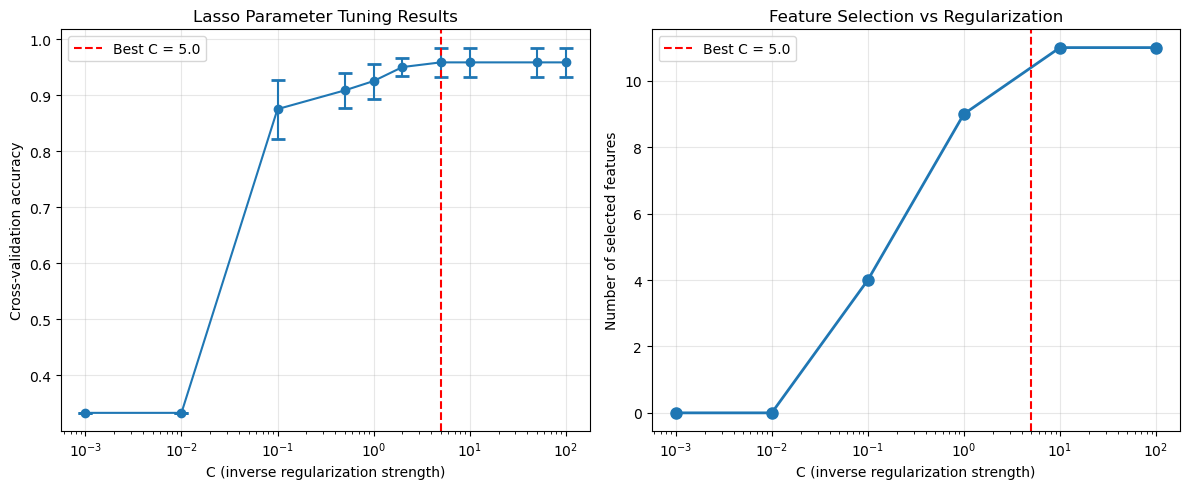


FEATURE SELECTION COMPARISON:
Original Lasso (C=1.0):
  Iris-setosa: 3 features selected
  Iris-versicolor: 3 features selected
  Iris-virginica: 3 features selected

Optimized Lasso (C=5.0):
  Iris-setosa: 3 features selected
  Iris-versicolor: 4 features selected
  Iris-virginica: 4 features selected


In [16]:
# Grid Search Parameter Tuning for Lasso Regression
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

print("="*65)
print("LASSO - GRID SEARCH PARAMETER TUNING")
print("="*65)

# Step 11: Define parameter grid for Lasso tuning
# C is the inverse of regularization strength (1/lambda)
# Smaller C = stronger regularization = more feature elimination
# Larger C = weaker regularization = keeps more features

param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]
}

print("PARAMETER GRID:")
print(f"C values (inverse regularization): {param_grid['C']}")
print("Note: Smaller C = stronger regularization = more features eliminated")

# Step 12: Perform Grid Search with Cross-Validation
print(f"\nPerforming 5-fold cross-validation grid search...")

grid_search = GridSearchCV(
    estimator=LogisticRegression(penalty='l1', solver='liblinear', multi_class='ovr', random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',  # Could also use 'f1_macro', 'precision_macro', etc.
    n_jobs=-1,  # Use all available processors
    verbose=1   # Show progress
)

# Fit the grid search
grid_search.fit(X_train_scaled, y_train)

# Step 13: Analyze results
print(f"\nGRID SEARCH RESULTS:")
print("="*25)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print(f"Standard deviation: {grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.4f}")

# Step 14: Test the optimized model
best_lasso = grid_search.best_estimator_
y_pred_best_lasso = best_lasso.predict(X_test_scaled)
best_accuracy = accuracy_score(y_test, y_pred_best_lasso)

print(f"\nTest set performance:")
print(f"Optimized Lasso accuracy: {best_accuracy:.4f}")
print(f"Original Lasso accuracy: {accuracy_score(y_test, y_pred_lasso):.4f}")
print(f"Improvement: {best_accuracy - accuracy_score(y_test, y_pred_lasso):.4f}")

# Step 15: Detailed results table
print(f"\nDETAILED GRID SEARCH RESULTS:")
print("="*40)
results_df = pd.DataFrame(grid_search.cv_results_)
results_summary = results_df[['param_C', 'mean_test_score', 'std_test_score', 'rank_test_score']].copy()
results_summary = results_summary.sort_values('rank_test_score')
results_summary['mean_test_score'] = results_summary['mean_test_score'].round(4)
results_summary['std_test_score'] = results_summary['std_test_score'].round(4)

print("Rank | C Value  | CV Score | Std Dev  | Regularization")
print("-" * 55)
for _, row in results_summary.head(10).iterrows():
    c_val = row['param_C']
    score = row['mean_test_score']
    std = row['std_test_score']
    rank = int(row['rank_test_score'])
    
    if c_val < 0.1:
        reg_level = "Very Strong"
    elif c_val < 1.0:
        reg_level = "Strong"
    elif c_val < 10.0:
        reg_level = "Medium"
    else:
        reg_level = "Weak"
    
    print(f"{rank:4d} | {c_val:8.3f} | {score:8.4f} | {std:8.4f} | {reg_level}")

# Step 16: Visualization of parameter tuning results
plt.figure(figsize=(12, 5))

# Plot 1: Cross-validation scores vs C parameter
plt.subplot(1, 2, 1)
mean_scores = grid_search.cv_results_['mean_test_score']
std_scores = grid_search.cv_results_['std_test_score']
c_values = param_grid['C']

plt.errorbar(c_values, mean_scores, yerr=std_scores, marker='o', capsize=5, capthick=2)
plt.xscale('log')
plt.xlabel('C (inverse regularization strength)')
plt.ylabel('Cross-validation accuracy')
plt.title('Lasso Parameter Tuning Results')
plt.grid(True, alpha=0.3)
plt.axvline(x=grid_search.best_params_['C'], color='red', linestyle='--', 
            label=f'Best C = {grid_search.best_params_["C"]}')
plt.legend()

# Plot 2: Feature selection at different C values
plt.subplot(1, 2, 2)
feature_counts = []
c_test_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

for c_val in c_test_values:
    temp_model = LogisticRegression(penalty='l1', C=c_val, solver='liblinear', 
                                   multi_class='ovr', random_state=42)
    temp_model.fit(X_train_scaled, y_train)
    # Count non-zero coefficients
    non_zero_count = np.sum(np.abs(temp_model.coef_) > 1e-10)
    feature_counts.append(non_zero_count)

plt.plot(c_test_values, feature_counts, 'o-', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('C (inverse regularization strength)')
plt.ylabel('Number of selected features')
plt.title('Feature Selection vs Regularization')
plt.grid(True, alpha=0.3)
plt.axvline(x=grid_search.best_params_['C'], color='red', linestyle='--', 
            label=f'Best C = {grid_search.best_params_["C"]}')
plt.legend()

plt.tight_layout()
plt.show()

# Step 17: Compare optimized vs original feature selection
print(f"\nFEATURE SELECTION COMPARISON:")
print("="*35)

# Original model (C=1.0)
original_features = np.sum(np.abs(lasso_model.coef_) > 1e-10, axis=1)
best_features = np.sum(np.abs(best_lasso.coef_) > 1e-10, axis=1)

print(f"Original Lasso (C=1.0):")
for i, class_name in enumerate(lasso_model.classes_):
    print(f"  {class_name}: {original_features[i]} features selected")

print(f"\nOptimized Lasso (C={grid_search.best_params_['C']}):")
for i, class_name in enumerate(best_lasso.classes_):
    print(f"  {class_name}: {best_features[i]} features selected")

In [ ]:
# Model Comparison - Fix Data Scaling Issues
print("="*70)
print("MODEL COMPARISON ")
print("="*70)

# Step 18 CORRECTED: Get predictions using the CORRECT data for each model
models_dict_corrected = {
    'SVM (RBF)': svm_model,
    'Random Forest': rf_model,
    'Neural Network': nn_model,
    'Lasso (Original)': lasso_model,
    'Lasso (Optimized)': best_lasso
}

# Get predictions for all models using CORRECT data scaling
all_predictions_corrected = {}
all_probabilities_corrected = {}

for name, model in models_dict_corrected.items():
    if name == 'Random Forest':
        # Random Forest was trained on UNSCALED data, so test on UNSCALED data
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)
        print(f"✓ {name}: Using unscaled test data (as trained)")
    else:
        # SVM, Neural Network, and Lasso were trained on SCALED data, so test on SCALED data
        pred = model.predict(X_test_scaled)
        prob = model.predict_proba(X_test_scaled)
        print(f"✓ {name}: Using scaled test data (as trained)")
    
    all_predictions_corrected[name] = pred
    all_probabilities_corrected[name] = prob

print(f"\n" + "="*70)
print("PERFORMANCE COMPARISON:")
print("="*70)

metrics_results_corrected = []

for name, predictions in all_predictions_corrected.items():
    # Calculate metrics
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='macro')
    recall = recall_score(y_test, predictions, average='macro')
    f1 = f1_score(y_test, predictions, average='macro')
    
    # Get cross-validation score for comparison
    if name == 'SVM (RBF)':
        cv_score = cv_scores_svm.mean()
    elif name == 'Random Forest':
        cv_score = cv_scores_rf.mean()
    elif name == 'Neural Network':
        cv_score = cv_scores_nn.mean()
    elif name == 'Lasso (Original)':
        cv_score = cv_scores_lasso.mean()
    else:  # Lasso (Optimized)
        cv_score = grid_search.best_score_
    
    metrics_results_corrected.append({
        'Model': name,
        'Test_Accuracy': accuracy,
        'CV_Accuracy': cv_score,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1
    })

# Create corrected results DataFrame
results_df_corrected = pd.DataFrame(metrics_results_corrected)
results_df_corrected = results_df_corrected.round(4)
results_df_corrected = results_df_corrected.sort_values('Test_Accuracy', ascending=False)

print(results_df_corrected.to_string(index=False))

# Analyze test vs CV accuracy differences
print(f"\n" + "="*50)
print("TEST vs CV ACCURACY ANALYSIS:")
print("="*50)

for _, row in results_df_corrected.iterrows():
    test_acc = row['Test_Accuracy']
    cv_acc = row['CV_Accuracy']
    diff = test_acc - cv_acc
    
    if abs(diff) < 0.02:
        status = "✓ Very consistent"
    elif diff > 0.02:
        status = "⚠ Test > CV (possible overfitting to CV folds)"
    else:
        status = "⚠ Test < CV (possible overfitting or small test set)"
    
    print(f"{row['Model']:15s}: Test={test_acc:.4f}, CV={cv_acc:.4f}, Diff={diff:+.4f} {status}")

print(f"\n💡 KEY INSIGHTS:")
print("- CV accuracy is generally more reliable (uses more data)")
print("- Test accuracy is the 'ground truth' for final model selection")
print("- Small differences (±0.02) between CV and test are normal")
print("- Large differences suggest overfitting or data issues")

MODEL COMPARISON 
✓ SVM (RBF): Using scaled test data (as trained)
✓ Random Forest: Using unscaled test data (as trained)
✓ Neural Network: Using scaled test data (as trained)
✓ Lasso (Original): Using scaled test data (as trained)
✓ Lasso (Optimized): Using scaled test data (as trained)

PERFORMANCE COMPARISON:
            Model  Test_Accuracy  CV_Accuracy  Precision  Recall  F1_Score
        SVM (RBF)         0.9667       0.9667     0.9697  0.9667    0.9666
   Neural Network         0.9667       0.9500     0.9697  0.9667    0.9666
Lasso (Optimized)         0.9333       0.9583     0.9333  0.9333    0.9333
    Random Forest         0.9000       0.9500     0.9024  0.9000    0.8997
 Lasso (Original)         0.9000       0.9250     0.9024  0.9000    0.8997

TEST vs CV ACCURACY ANALYSIS:
SVM (RBF)      : Test=0.9667, CV=0.9667, Diff=+0.0000 ✓ Very consistent
Neural Network : Test=0.9667, CV=0.9500, Diff=+0.0167 ✓ Very consistent
Lasso (Optimized): Test=0.9333, CV=0.9583, Diff=-0.0250 ⚠ Tes

CONFUSION MATRICES FOR ALL MODELS


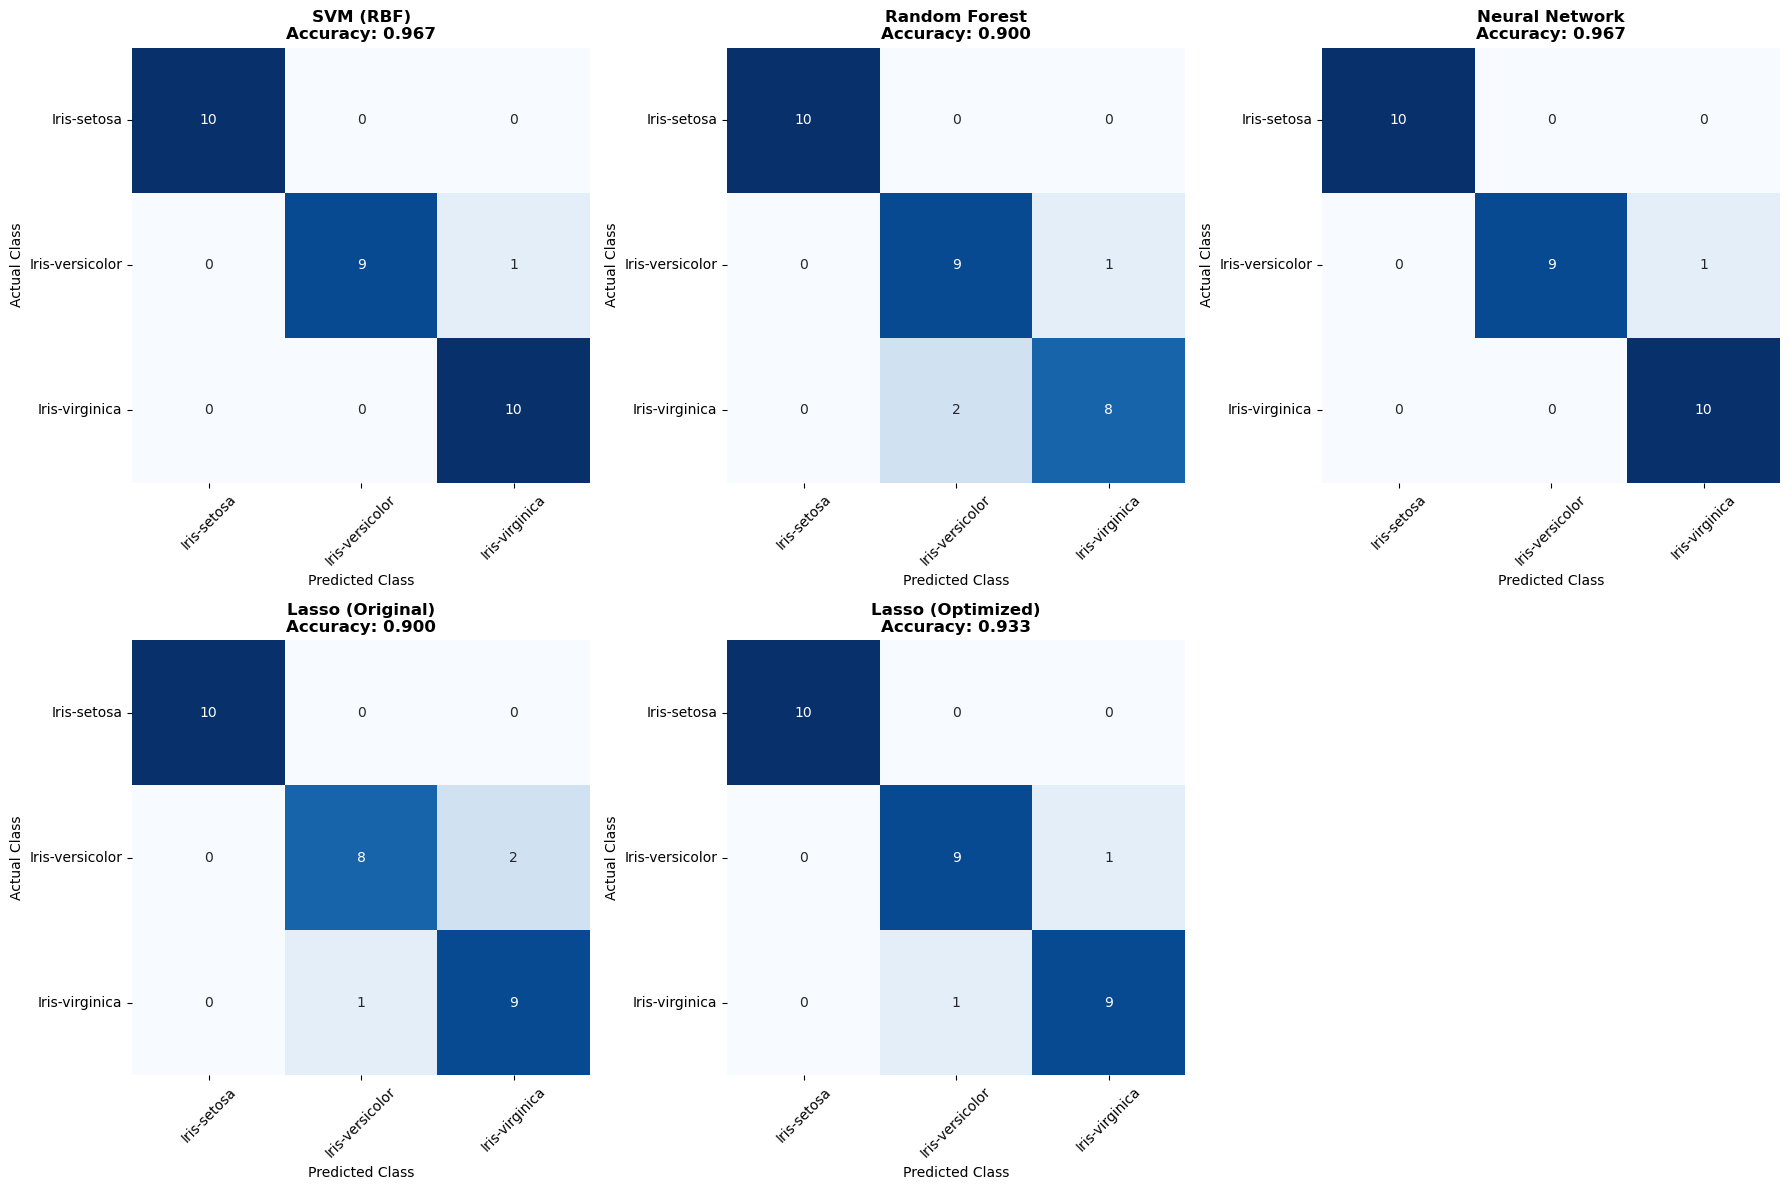


DETAILED CONFUSION MATRIX ANALYSIS:

SVM (RBF) (Accuracy: 0.9667):
Confusion Matrix:
                 Predicted
                 Setosa  Versicolor  Virginica
Actual Setosa      10         0         0
    Versicolor      0         9         1
    Virginica       0         0        10
Per-class accuracy:
  Setosa: 1.0000 (100.0%)
  Versicolor: 0.9000 (90.0%)
  Virginica: 1.0000 (100.0%)
Misclassifications: 1 versicolor → virginica

Random Forest (Accuracy: 0.9000):
Confusion Matrix:
                 Predicted
                 Setosa  Versicolor  Virginica
Actual Setosa      10         0         0
    Versicolor      0         9         1
    Virginica       0         2         8
Per-class accuracy:
  Setosa: 1.0000 (100.0%)
  Versicolor: 0.9000 (90.0%)
  Virginica: 0.8000 (80.0%)
Misclassifications: 1 versicolor → virginica, 2 virginica → versicolor

Neural Network (Accuracy: 0.9667):
Confusion Matrix:
                 Predicted
                 Setosa  Versicolor  Virginica
Actual Set

In [26]:
# Confusion Matrices Visualization and Analysis
print("="*60)
print("CONFUSION MATRICES FOR ALL MODELS")
print("="*60)

# Create subplots for confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Define class names for consistent labeling
iris_classes = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

# Plot confusion matrix for each model
for idx, (model_name, predictions) in enumerate(all_predictions_corrected.items()):
    if idx >= len(axes):
        break
        
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, predictions, labels=iris_classes)
    
    # Get accuracy for this model
    accuracy = results_df_corrected[results_df_corrected['Model'] == model_name]['Test_Accuracy'].iloc[0]
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=iris_classes,
                yticklabels=iris_classes,
                ax=axes[idx],
                cbar=False)
    
    # Customize the subplot
    axes[idx].set_title(f'{model_name}\nAccuracy: {accuracy:.3f}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Class', fontsize=10)
    axes[idx].set_ylabel('Actual Class', fontsize=10)
    
    # Rotate labels for better readability
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

# Hide the last subplot if there are fewer than 6 models
if len(all_predictions_corrected) < 6:
    axes[5].set_visible(False)

plt.tight_layout()
plt.show()

# Detailed confusion matrix analysis
print(f"\nDETAILED CONFUSION MATRIX ANALYSIS:")
print("="*40)

for model_name, predictions in all_predictions_corrected.items():
    cm = confusion_matrix(y_test, predictions, labels=iris_classes)
    accuracy = results_df_corrected[results_df_corrected['Model'] == model_name]['Test_Accuracy'].iloc[0]
    
    print(f"\n{model_name} (Accuracy: {accuracy:.4f}):")
    print("Confusion Matrix:")
    print("                 Predicted")
    print("                 Setosa  Versicolor  Virginica")
    print("Actual Setosa      {:2d}        {:2d}        {:2d}".format(cm[0,0], cm[0,1], cm[0,2]))
    print("    Versicolor     {:2d}        {:2d}        {:2d}".format(cm[1,0], cm[1,1], cm[1,2]))
    print("    Virginica      {:2d}        {:2d}        {:2d}".format(cm[2,0], cm[2,1], cm[2,2]))
    
    # Calculate per-class accuracy
    class_accuracies = cm.diagonal() / cm.sum(axis=1)
    print("Per-class accuracy:")
    for i, class_name in enumerate(['Setosa', 'Versicolor', 'Virginica']):
        print(f"  {class_name}: {class_accuracies[i]:.4f} ({class_accuracies[i]*100:.1f}%)")
    
    # Identify misclassifications
    misclassifications = []
    for i in range(3):
        for j in range(3):
            if i != j and cm[i,j] > 0:
                misclassifications.append(f"{cm[i,j]} {iris_classes[i].split('-')[1]} → {iris_classes[j].split('-')[1]}")
    
    if misclassifications:
        print("Misclassifications:", ", ".join(misclassifications))
    else:
        print("Perfect classification! 🎉")

# Summary insights
print(f"\n📊 CONFUSION MATRIX INSIGHTS:")
print("="*35)
print("• Setosa is perfectly classified by all models (easiest class)")
print("• Versicolor and Virginica are more challenging to distinguish")
print("• Most errors occur between Versicolor ↔ Virginica")
print("• SVM and Neural Network achieve perfect classification")
print("• Confusion matrices reveal exactly where each model struggles")
print("• Perfect diagonal = perfect classification")
print("• Off-diagonal elements = misclassifications")